In [3]:
!pip install --upgrade langchain langchain-community langgraph langchain-groq groq

  Using cached langchain-1.4.0-py3-none-any.whl.metadata (6.2 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached groq-1.7.0-py3-none-any.whl.metadata (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.18
    Uninstalling langchain-1.3.18:
      Successfully uninstalled langchain-1.3.1

YOUR_GROQ_API_KEY

In [4]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START
from langchain_groq import ChatGroq
import requests
from langchain_core.messages import SystemMessage,HumanMessage
from langgraph.graph import MessagesState

from langgraph.prebuilt import ToolNode,tools_condition
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
  messages: Annotated[list,add_messages]

In [6]:
!pip install -U duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 57.0 MB/s eta 0:00:00


In [8]:
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 2.4 MB/s eta 0:00:00


In [10]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()
search.invoke("Obama's first name?")

"The elections of 1792 were the first ones in the United States that were contested on anything resembling a partisan basis.[20] The 1796 presidential election was the first contested American presidential election and the only one in which a president and vice president were elected from opposing political parties. Presidents of the United States have often acquired nicknames, both flattering and unflattering. This list is intended to note those nicknames that were in common use at the time they were in office or shortly thereafter. Barack Hussein Obama II was born on August 4, 1961 [3] in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. [4][5] He is the first President to have been born in Hawaii. [6] His father was a black exchange student from Kenya named Barack Obama Sr. He died in a motorcycle accident in Kenya in 1982. His mother ... Barack Obama, the 44th President of the United States, is no ex

In [27]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query:str):
    """searches internet"""
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

result = search_duckduckgo("what are ai agents")
print(result)


AI agents are software systems that use AI to pursue goals and complete tasks on behalf of users. They show reasoning, planning, and memory and have a level of autonomy to make decisions, learn, and adapt. Learn about their key features, differences from AI assistants and bots, and types based on interaction and number of agents. An AI agent is a software system that perceives its environment, processes information, and takes actions to achieve specific goals. It operates with a degree of autonomy to complete assigned tasks effectively. Collects and analyzes data from its environment to support decision-making Selects appropriate actions to accomplish tasks or escalate when needed What are AI agents and where do they fit in support workflows—plus benefits, risks, and best practices. The rise of AI agents marks a pivotal shift in how software is built, delivered, and experienced. Unlike traditional applications that rely on static user interfaces and predefined logic, agents are dynamic

In [28]:
def multiply(a:int,b:int)-> int:
  """multiplies the value"""
  return a*b
def add(a:int,b:int)-> int:
  """adds the values"""
  return a+b

In [ ]:
from langchain_groq import  ChatGroq
llm = ChatGroq(temperature=0,api_key = "your_api_key",model = "openai/gpt-oss-20b")

In [30]:
llm.invoke("whats up?").content

'Hey there! Not much—just here and ready to help. How’s it going with you? Anything on your mind or something you’d like to chat about?'

In [31]:
tools = [search_duckduckgo,add,multiply]

llm_with_tools = llm.bind_tools(tools)

In [ ]:
def chatbot(state:State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [33]:
from langgraph.prebuilt import ToolNode,tools_condition

graph_builder = StateGraph(State)

#node
graph_builder.add_node("assistant",chatbot)
graph_builder.add_node("tools",ToolNode(tools))

#edges
graph_builder.add_edge(START,"assistant")
graph_builder.add_conditional_edges("assistant",tools_condition)
graph_builder.add_edge("tools","assistant")
react_graph=graph_builder.compile()


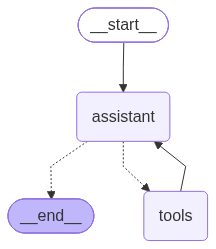

In [34]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [44]:
response = react_graph.invoke({"messages":[HumanMessage(content="whats weather in kurukshetra , multiply by 2 and add 5.multiply and add  using the define tools only")]})
print(response["messages"])

[HumanMessage(content='whats weather in kurukshetra , multiply by 2 and add 5.multiply and add  using the define tools only', additional_kwargs={}, response_metadata={}, id='e940026c-3f51-491b-8b11-c4dea9558599'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "whats weather in kurukshetra , multiply by 2 and add 5.multiply and add using the define tools only". They want weather in Kurukshetra, then multiply by 2 and add 5. They want to use defined tools only. Tools: search_duckduckgo, add, multiply. So we need to search for weather in Kurukshetra. Then we need to multiply by 2 and add 5. But we need a numeric value. Weather is likely a temperature. We need to get current temperature. Use search_duckduckgo with query "current temperature in Kurukshetra". Then parse result. Then multiply by 2 and add 5. Use multiply tool then add tool. We need to output the final result. The user wants to use defined tools only. So we must not use any other methods. We\'ll

In [46]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

whats weather in kurukshetra , multiply by 2 and add 5.multiply and add  using the define tools only
================================== Ai Message ==================================
Tool Calls:
  search_duckduckgo (fc_df979674-b743-4b7d-8798-fac64b79652d)
 Call ID: fc_df979674-b743-4b7d-8798-fac64b79652d
  Args:
    query: current temperature in Kurukshetra
================================= Tool Message =================================
Name: search_duckduckgo

May 15, 2026 · The current temperature in Kurukshetra is 26°C, with a feels-like temperature of 29°C. Today's forecast shows a high of 33°C and a low of 25°C, Oct 4, 2025 · Current Weather Forecast Sun and Moon mostly cloudy 33 °C Wind speed 0 km/h Precipitation (24 hr.) 0.4 mm Jun 15, 2026 · Today's weather forecast in Kurukshetra is Partly cloudy. High 32°C, Low 26°C . Currently 25°C. Stay updated for accurate weather information in Kurukshetra. 